In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import pandas as pd
import re
from tqdm import notebook
import time
import warnings

In [2]:
def _dataread(self, filename, fix_cycle_numbers=False):
    data_raw = []
    
    ## For fixing cycle numbers
    limits = {}
    target = "none_selected_"

    with open(filename) as f:
        print("Reading .mpt file")
        for line in notebook.tqdm(f.readlines()):
            if "Nb header lines" in line:
                headers = int(re.findall(r"\d+", line)[0])

            if "rec" in line and "type" in line and "Time" in line:
                target = line.split("\t")[0].split("_")[0]

            if target in line:
                parts = re.split(r"\s{2,}", line.strip())
                limits.update([(parts[0], parts[1:])])

            data_raw.append(line.strip("\n").split("\t"))

    columns = data_raw[headers-1]
    try:
        data_read = np.array([line for line in data_raw[headers:] if "mode" not in line], dtype=float) ## changed 13/04/2026
    except:
        data_read = np.array([line for line in data_raw[headers:] if "mode" not in line and len(line)>1], dtype=float) ## Fix if possible
    
    
    df = pd.DataFrame(data_read, columns=columns[:data_read.shape[1]])
    self._df = df ## keeping raw df available

    if fix_cycle_numbers==True:
        limits = pd.DataFrame(limits)
        limits.columns = ["_".join((column.split("_")[1:])) for column in limits.columns]
        limits["value"] = limits["value"].astype(float)

        time = df["time/s"].to_numpy()
        cycle_breaks = np.nonzero(time[1:]-time[:-1]>2*max(limits["value"]))[0]
        cycle_breaks = np.insert(cycle_breaks, 0, 0)
        cycle_breaks = np.append(cycle_breaks, len(df))

        for nidx, idx in enumerate(cycle_breaks[:-1]):
            df.loc[cycle_breaks[nidx]: cycle_breaks[nidx+1], "cycle number"] = nidx
            
            
        ## Added 29/04/2026
        df_adj = self._df.copy()

        for cycn in np.unique(self._df["cycle number"]):
            cycle_df = self._df.loc[self._df["cycle number"]==cycn]

            ## Adjusting Q discharge/mA.h
            original_Qdischarge = cycle_df["Q discharge/mA.h"].to_numpy()
            min_Qdischarge = np.nanmin(original_Qdischarge)
            adjusted_Qdischarge = original_Qdischarge-min_Qdischarge
            df_adj.loc[cycle_df.index, "Q discharge/mA.h"] = adjusted_Qdischarge


            ## Adjusting Q charge/mA.h
            original_Qcharge = cycle_df["Q charge/mA.h"].to_numpy()
            min_Qcharge = np.nanmin(original_Qcharge)
            adjusted_Qcharge = cycle_df["Q charge/mA.h"]-min_Qcharge
            df_adj.loc[cycle_df.index, "Q charge/mA.h"] = adjusted_Qcharge

            ## Adjusting Q charge/discharge/mA.h
            original_Qchargedischarge = cycle_df["Q charge/discharge/mA.h"].to_numpy()
            min_Qchargedischarge = np.nanmin(original_Qchargedischarge)
            adjusted_Qchargedischarge = cycle_df["Q charge/discharge/mA.h"]-min_Qchargedischarge
            df_adj.loc[cycle_df.index, "Q charge/discharge/mA.h"] = adjusted_Qchargedischarge
        self._df = df_adj

  

In [3]:
  
def _annotate_raw(self):
    raw = self._df[["time/s", "cycle number", "I/mA", "Ecell/V", "Q charge/mA.h", "Q discharge/mA.h"]]
    raw.columns = ["t", "cycn", "I", "E", "cQ", "dQ"]

    raw = raw.copy()
    raw.loc[:, "cQ"] = raw["cQ"]
    raw.loc[:, "dQ"] = raw["dQ"]
    raw.loc[:, "I"] = raw["I"]*1e-3

    # 1) compute state column: "R" if I==0, "D" if I<0, "C" if I>0
    def compute_state(i_val):
        if pd.isna(i_val):
            return np.nan
        if i_val == 0:
            return "R"
        if i_val < 0:
            return "D"
        if i_val > 0:
            return "C"
    
    raw.loc[:, "state"] = raw["I"].apply(compute_state)
    
    # 2) compute rests: increment counter each time we observe a transition into "R"
    rests = []
    count_rest = 0
    states = raw["state"].tolist()

    for idx, st in enumerate(states):
        if idx == 0:
            # first row: count_rest stays 0
            rests.append(count_rest)
            continue

        prev_st = states[idx - 1]
        # transition into R from non-R
        if st == "R" and prev_st != "R":
            count_rest += 1
        rests.append(count_rest)

    raw = raw.copy()
    raw.loc[:, "rests"] = rests

    # 3) adjQ = dQ - cQ
    raw.loc[:, "adjQ"] = raw["dQ"] - raw["cQ"]

    self.raw = raw
    

In [4]:
    
def f_R(self, rest_index):
    """
    rest_index here corresponds to the integer i used in the R code.
    We'll implement:
      numerator = last E where (rests == rest_index) & (state == "R") 
                  minus last E where rests == rest_index-1
      denominator = -1 * last I where rests == rest_index-1
    Return numerator / denominator or np.nan if not computable.
    """
    prev = rest_index - 1

    # rows for current rest_index with state == "R"
    sel_current_R = self.raw[(self.raw["rests"] == rest_index) & (self.raw["state"] == "R")]
    # rows for previous rest index (no state restriction)
    sel_prev = self.raw[self.raw["rests"] == prev]

    try:
        E_current = sel_current_R["E"].iloc[-1]  # tail(...,1)
    except (IndexError, KeyError):
        E_current = np.nan

    try:
        E_prev = sel_prev["E"].iloc[-1]
    except (IndexError, KeyError):
        E_prev = np.nan

    try:
        I_prev = sel_prev["I"].iloc[-1]
    except (IndexError, KeyError):
        I_prev = np.nan

    # denominator = -1 * I_prev
    denom = -1.0 * I_prev if pd.notna(I_prev) else np.nan

    # if denom is zero or any required value is nan, return NaN
    if denom == 0 or not np.isfinite(denom) or not np.isfinite(E_current) or not np.isfinite(E_prev):
        return np.nan

    return (E_current - E_prev) / denom

In [5]:
def _proc_data(self):
    max_rest = int(self.raw["rests"].max()) if not self.raw["rests"].isnull().all() else 0
    rest_list = list(range(1, max_rest + 1))
    proc_columns = ["rest", "state", "cycn", "Q", "E", "R"]
    proc_rows = dict([(keys, []) for keys in proc_columns])
    
    print("ICI calculation")
    for r in notebook.tqdm(rest_list):
        prev = r - 1
        sel_prev = self.raw[self.raw["rests"] == prev]

        # get tail values from previous rest (if available), otherwise NaN
        if not sel_prev.empty:
            last_state = sel_prev["state"].iloc[-1]
            last_cycn = sel_prev["cycn"].iloc[-1] if "cycn" in sel_prev else np.nan
            last_adjQ = sel_prev["adjQ"].iloc[-1] if "adjQ" in sel_prev else np.nan
            last_E = sel_prev["E"].iloc[-1] if "E" in sel_prev else np.nan
        else:
            last_state = np.nan
            last_cycn = np.nan
            last_adjQ = np.nan
            last_E = np.nan

        proc_rows["rest"].append(r)
        proc_rows["state"].append(last_state)
        proc_rows["cycn"].append(last_cycn)
        proc_rows["Q"].append(last_adjQ)
        proc_rows["E"].append(last_E)
        proc_rows["R"].append(f_R(self, r))
        
    proc = pd.DataFrame(proc_rows)

    # 6) replace non-finite proc.R with NaN (matches R's is.finite/NA behavior)
    proc.loc[:, "R"] = proc["R"].apply(lambda v: v if np.isfinite(v) else np.nan)

    self.proc = proc
  

In [6]:
class ICI(object):
    def __init__(self, filename, reload=True, fix_cycle_numbers=False):
        
        self._version = "2026.03.23"
        self._change_log = {"2026.03.14": "Added line in data read to ensure repeated headers are not included",
                            "2026.03.23": "Split out functions for ease of diagnostics"}
        
        warnings.filterwarnings(action="ignore", message="SettingWithCopyWarning")
        
        ## Checking when the raw datafile was last updated: used for ongoing data
        self.filename = os.path.split(filename)[-1].strip(".mpt") ## used for labelling later
        self.path = os.path.split(filename)[0]
        self._pfilename = filename
        creation_time = os.path.getmtime(filename)
        time_str = "%d/%m/%Y %H:%M:%S"
        self.data_last_updated = time.strftime(time_str, time.localtime(creation_time))
        
        ## Processed filenames: for checking and saving        
        processed_fname = os.path.join(self.path, self.filename+"_processed.csv")
        processed_exists = os.path.isfile(processed_fname)
        
        ## Case 1: no rawchargedischarge, or reloading
        if processed_exists==False or reload==False: ## changed 29.04.2026
            ## Read from the mpt file
            _dataread(self, filename, fix_cycle_numbers=fix_cycle_numbers)
            
            ## Annotate the data with charge/ discharge/ rest
            _annotate_raw(self)
            raw_chargedischarge = self.raw.loc[self.raw["state"]!="R"]
            raw_chargedischarge.to_csv(os.path.join(self.path, self.filename+"_raw_chargedischarge.csv"))
            
            ## Calculate the internal resistance
            _proc_data(self)
            self.proc.to_csv(processed_fname)
            
        ## Case 2: prevous rawchargedischarge exists 
        if processed_exists==True and reload==True: ## changed 29.04.2026
            self.raw = pd.read_csv(os.path.join(self.path, self.filename+"_raw_chargedischarge.csv"),
                                   index_col=0)
            self.proc = pd.read_csv(os.path.join(self.path, self.filename+"_processed.csv"), index_col=0)

In [7]:
path = r"C:\Users\Admin\OneDrive - Nexus365\Documents\Rate_capability_benchmark\ici_data\slowdischarge_fastcharge\sample1"
filename = '260415_Liam_ICI_disch01C_charge05C_resume_unknownstop3_02_MB_CF4.mpt'


## fixing filenames stage - only need self._df
self = ICI(os.path.join(path, filename),
                 fix_cycle_numbers=True, reload=False)


Reading .mpt file


  0%|          | 0/638875 [00:00<?, ?it/s]

ICI calculation


  0%|          | 0/1159 [00:00<?, ?it/s]

In [12]:
self._df["Capacity/mA.h"]

0           0.000000
1           0.001406
2           0.001406
3           0.004269
4           0.007133
             ...    
638759    147.564793
638760    147.567657
638761    147.570521
638762    147.573385
638763    147.576249
Name: Capacity/mA.h, Length: 638764, dtype: float64

In [ ]:
# if fix_cycle_numbers == True

In [13]:
df_adj = self._df.copy()

for cycn in np.unique(self._df["cycle number"]):
    cycle_df = self._df.loc[self._df["cycle number"]==cycn]
    
    ## Adjusting Q discharge/mA.h
    original_Qdischarge = cycle_df["Q discharge/mA.h"].to_numpy()
    min_Qdischarge = np.nanmin(original_Qdischarge)
    adjusted_Qdischarge = original_Qdischarge-min_Qdischarge
    df_adj.loc[cycle_df.index, "Q discharge/mA.h"] = adjusted_Qdischarge

    
    ## Adjusting Q charge/mA.h
    original_Qcharge = cycle_df["Q charge/mA.h"].to_numpy()
    min_Qcharge = np.nanmin(original_Qcharge)
    adjusted_Qcharge = cycle_df["Q charge/mA.h"]-min_Qcharge
    df_adj.loc[cycle_df.index, "Q charge/mA.h"] = adjusted_Qcharge

    ## Adjusting Q charge/discharge/mA.h
    original_Qchargedischarge = cycle_df["Q charge/discharge/mA.h"].to_numpy()
    min_Qchargedischarge = np.nanmin(original_Qchargedischarge)
    adjusted_Qchargedischarge = original_Qchargedischarge-min_Qchargedischarge
    df_adj.loc[cycle_df.index, "Q charge/discharge/mA.h"] = adjusted_Qchargedischarge 
    
    ## Adjusting Capacity/mA.h
    original_capacity = cycle_df["Capacity/mA.h"].to_numpy()
    min_capacity = np.nanmin(original_capacity)
    adjusted_capacity = original_capacity-min_capacity
    df_adj.loc[cycle_df.index, "Capacity/mA.h"] = adjusted_capacity

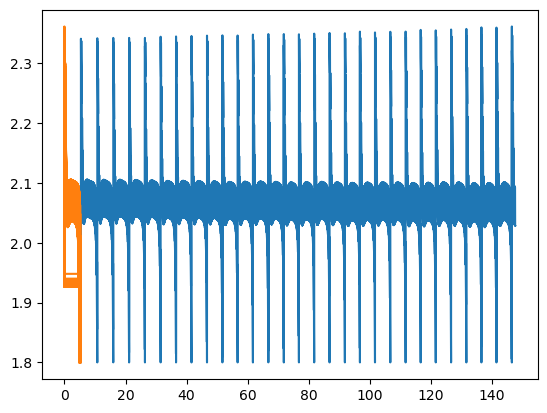

In [15]:
fig, ax = plt.subplots()
# ax.plot(self._df["Q discharge/mA.h"], self._df["Ecell/V"])
ax.plot(self._df["Capacity/mA.h"], self._df["Ecell/V"])
ax.plot(df_adj["Capacity/mA.h"], df_adj["Ecell/V"])

In [ ]:
## Find rows where incremented
cycle_number = self._df["cycle number"].to_numpy()
cycle_changes = 1+np.nonzero(cycle_number[1:]!=cycle_number[:-1])[0]

In [ ]:
self._df.iloc[cycle_changes[1]-5:cycle_changes[1]+20]